In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv("/mnt/d/Datasets/diabetes.csv")

In [2]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
import tensorflow as tf
from tensorflow import keras

I0000 00:00:1787835535.724967  190682 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787835538.318842  190682 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787835627.422260  190682 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
X=st.fit_transform(X)

In [6]:
X.shape

(768, 8)

In [7]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [8]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
X=st.fit_transform(X)

In [9]:
from keras.layers import Dense
from keras import Sequential
model =  Sequential()
model.add(Dense(32,activation='relu',input_dim=8))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation="sigmoid"))

/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1787835741.290592  190682 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:
model.compile(optimizer='adam',loss=['binary_crossentropy'])

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.35)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
loss=model.fit(X_train,y_train,epochs=250,validation_data=(X_test,y_test))

Epoch 1/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.6795 - val_loss: 0.6642
Epoch 2/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6566 - val_loss: 0.6437
Epoch 3/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6340 - val_loss: 0.6191
Epoch 4/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6086 - val_loss: 0.5905
Epoch 5/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5807 - val_loss: 0.5603
Epoch 6/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5539 - val_loss: 0.5318
Epoch 7/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5307 - val_loss: 0.5075
Epoch 8/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5112 - val_loss: 0.4914
Epoch 9/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4983 - val_loss: 0.4792
Epoch 10/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4887 - val_loss: 0.4706
Epoch 11/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4813 - val_loss: 0.4651
Epoch 12/250
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.

In [ ]:
import matplotlib.pyplot as  plt
plt.plot(loss.history['loss'])
plt.plot(loss.history['val_loss'])



In [17]:
import keras_tuner as kt
def build_model(hp):
    model = Sequential()
    model.add(Dense(32,activation='relu',input_dim=8))
    model.add(Dense(1,activation='sigmoid'))
    optimizer=hp.Choice("optimizer",values=["adam","sgd","rmsprop","adadelta"])
    model.compile(optimizer=optimizer,loss='binary_crossentropy',metrics=['accuracy'])
    return model
# now we will make a tuner object which will have 
tuner = kt.RandomSearch(build_model,objective="val_accuracy",max_trials=100)
tuner.search(X_train,y_train,epochs=10,validation_data=(X_test,y_test))


Trial 4 Complete [00h 00m 03s]
val_accuracy: 0.7397769689559937

Best val_accuracy So Far: 0.74349445104599
Total elapsed time: 00h 00m 22s


In [22]:
tuner.get_best_hyperparameters()[0].values


{'optimizer': 'adam'}

In [23]:
model = tuner.get_best_models(num_models=1)[0]

/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(store)


In [24]:
model.fit(X_train,y_train,epochs=100,initial_epoch=6,validation_data=(X_test,y_test))

Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7715 - loss: 0.4741 - val_accuracy: 0.7361 - val_loss: 0.5090
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7756 - loss: 0.4673 - val_accuracy: 0.7509 - val_loss: 0.5060
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7796 - loss: 0.4618 - val_accuracy: 0.7435 - val_loss: 0.5042
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7836 - loss: 0.4581 - val_accuracy: 0.7361 - val_loss: 0.5030
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7856 - loss: 0.4541 - val_accuracy: 0.7361 - val_loss: 0.5019
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7856 - loss: 0.4513 - val_accuracy: 0.7472 - val_loss: 0.5015
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7856 - loss: 0.4491 - val_accuracy: 0.7546 - val_loss: 0.5014
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7896 - loss: 0.4466 - val_accuracy: 0.75

### Tuning the Number of Nodes now

In [38]:
def build_model(hp):
    model = Sequential()
    units = hp.Int('units',min_value=8,max_value=256,step=8)
    model.add(Dense(units=units,activation='relu',input_dim=8))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    return model

    

In [39]:
tuner = kt.RandomSearch(build_model,objective='val_accuracy',max_trials=10,overwrite=True)

/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
tuner.search(X_train,y_train,epochs=50,validation_data=(X_test,y_test))

Trial 10 Complete [00h 00m 07s]
val_accuracy: 0.7546468377113342

Best val_accuracy So Far: 0.7732341885566711
Total elapsed time: 00h 01m 09s


In [48]:
tuner.get_best_hyperparameters()[0].values

{'units': 104}

In [55]:
model = tuner.get_best_models(num_models=1)[0]

/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/mnt/d/DL-Algorithm/lvenv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(store)


In [56]:
from keras.layers import Dense
from keras import Sequential
model =  Sequential()
model.add(Dense(104,activation='relu',input_dim=8))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation="sigmoid"))

In [57]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [67]:
history=model.fit(X_train,y_train,epochs=200,validation_data=(X_test,y_test))

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0151 - val_accuracy: 0.7398 - val_loss: 1.4936
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0156 - val_accuracy: 0.7398 - val_loss: 1.4840
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 0.7472 - val_loss: 1.5054
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9980 - loss: 0.0147 - val_accuracy: 0.7361 - val_loss: 1.4963
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0163 - val_accuracy: 0.7286 - val_loss: 1.4742
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9980 - loss: 0.0186 - val_accuracy: 0.7435 - val_loss: 1.5004
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9960 - loss: 0.0168 - val_accuracy: 0.7398 - val_loss: 1.5294
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9980 - loss: 0.0156 - val_accuracy: 0.7398 - v

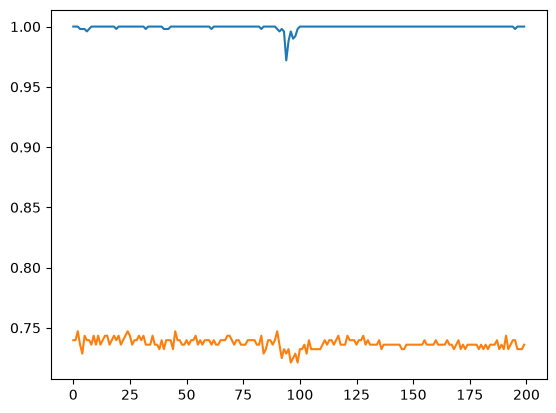

In [69]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')


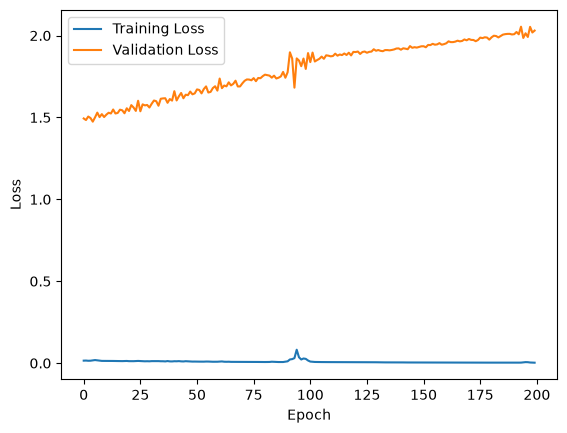

In [70]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [79]:

## Checking for the number of layers in the device
def build_model(hp):
    model= Sequential()
    model.add(Dense(104,activation='relu',input_dim=8))
    for i in range(hp.Int('num_layers',min_value=1,max_value=10)):
        model.add(Dense(104,activation='relu'))
    model.add(Dense(1,activation='sigmoid'))
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    return model


                   

In [ ]:
tuner =  kt.RandomSearch(build_model,objective=)

In [81]:
tuner.search(X_train,y_train,epochs=50,validation_data=(X_test,y_test))

Trial 10 Complete [00h 00m 06s]
val_accuracy: 0.7657992839813232

Best val_accuracy So Far: 0.7843866348266602
Total elapsed time: 00h 01m 04s


In [114]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_models(hp):
    model = Sequential()
    
    # Define hyperparameters ONCE outside the loop
    units = hp.Int('units', min_value=8, max_value=128, step=8)
    activation = hp.Choice('activation', values=['relu', 'tanh', 'sigmoid'])
    optimizer = hp.Choice('opt', values=['rmsprop', 'sgd', 'adam', 'adadelta'])
    
    for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
        if(i == 0):
            model.add(Dense(units, activation=activation, input_dim=8))
        else:
            model.add(Dense(units, activation=activation))
    
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(build_models, objective='val_accuracy', max_trials=5, overwrite=True)

tuner.search(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

# Get best hyperparameters
best_hps = tuner.get_best_hyperparameters()[0]
print(best_hps.values)

# See all trials
for trial in tuner.oracle.trials.values():
    print(trial.hyperparameters.values)

# Results summary
results = tuner.results_summary()
print(results)

Trial 5 Complete [00h 00m 09s]
val_accuracy: 0.7620818018913269

Best val_accuracy So Far: 0.7732341885566711
Total elapsed time: 00h 00m 53s
{'units': 104, 'activation': 'tanh', 'opt': 'adam', 'num_layers': 5}
{'units': 96, 'activation': 'tanh', 'opt': 'adadelta', 'num_layers': 3}
{'units': 72, 'activation': 'relu', 'opt': 'adam', 'num_layers': 3}
{'units': 104, 'activation': 'tanh', 'opt': 'adam', 'num_layers': 5}
{'units': 72, 'activation': 'relu', 'opt': 'adam', 'num_layers': 7}
{'units': 40, 'activation': 'relu', 'opt': 'sgd', 'num_layers': 1}
Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 2 summary
Hyperparameters:
units: 104
activation: tanh
opt: adam
num_layers: 5
Score: 0.7732341885566711

Trial 3 summary
Hyperparameters:
units: 72
activation: relu
opt: adam
num_layers: 7
Score: 0.7732341885566711

Trial 4 summary
Hyperparameters:
units: 40
activation: relu
opt: sgd
num_layers: 1
Score: 0.762081801891